출처: https://github.com/zhouhaoyi/Informer2020

# 1. 단변량

In [22]:
# 1. 라이브러리 임포트 및 설정
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from exp.exp_informer import Exp_Informer

# GPU 사용 가능 여부 확인 및 설정
use_gpu = torch.cuda.is_available()
device = torch.device('cuda' if use_gpu else 'cpu')
print("Device:", device)

# 2. Args 직접 정의 (main_informer.py argparse 역할)
class Args:
    model = 'informer'
    data = 'kospi200'
    root_path = '../YOLO-Futures/data/processed/'
    data_path = 'kospi200_ffill_clean_version.pkl'
    features = 'S'
    target = 'close'
    freq = 'h'
    detail_freq = 'h'
    checkpoints = './checkpoints/'
    seq_len = 96
    label_len = 48
    pred_len = 24
    enc_in = 1
    dec_in = 1
    c_out = 1
    d_model = 512
    n_heads = 8
    e_layers = 2
    d_layers = 1
    s_layers = '3,2,1'
    d_ff = 2048
    factor = 5
    padding = 0
    distil = True
    dropout = 0.05
    attn = 'prob'
    embed = 'timeF'
    activation = 'gelu'
    output_attention = False
    do_predict = True
    mix = True
    cols = None
    num_workers = 0
    itr = 1
    train_epochs = 6
    batch_size = 32
    patience = 3
    learning_rate = 0.0001
    des = 'test'
    loss = 'mse'
    lradj = 'type1'
    use_amp = False
    inverse = False
    use_gpu = use_gpu
    gpu = 0
    use_multi_gpu = False
    devices = '0,1,2,3'
    device_ids = None

args = Args()

# 3. Exp_Informer 객체 생성
exp = Exp_Informer(args)

# 4. 학습 시작
setting = f'{args.model}_{args.data}_ft{args.features}_sl{args.seq_len}_ll{args.label_len}_pl{args.pred_len}_dm{args.d_model}_nh{args.n_heads}_el{args.e_layers}_dl{args.d_layers}_df{args.d_ff}_at{args.attn}_fc{args.factor}_eb{args.embed}_dt{args.distil}_mx{args.mix}_{args.des}_0'

print(f"Training start: {setting}")
model = exp.train(setting)

# 5. 테스트
print(f"Testing start: {setting}")
exp.test(setting)

# 6. 예측 (미래 데이터에 대한)
if args.do_predict:
    print(f"Predicting start: {setting}")
    exp.predict(setting, load=True)



Device: cuda
Use GPU: cuda:0
Training start: informer_kospi200_ftS_sl96_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0
train 3381
val 477
test 977
	iters: 100, epoch: 1 | loss: 0.1607560
	speed: 0.1190s/iter; left time: 63.1626s
Epoch: 1 cost time: 12.542052745819092
Epoch: 1, Steps: 105 | Train Loss: 0.1980887 Vali Loss: 0.0341544 Test Loss: 0.8252889
Validation loss decreased (inf --> 0.034154).  Saving model ...
Updating learning rate to 0.0001
	iters: 100, epoch: 2 | loss: 0.0828397
	speed: 0.1540s/iter; left time: 65.6202s
Epoch: 2 cost time: 12.267906904220581
Epoch: 2, Steps: 105 | Train Loss: 0.1002224 Vali Loss: 0.0189455 Test Loss: 0.4834810
Validation loss decreased (0.034154 --> 0.018945).  Saving model ...
Updating learning rate to 5e-05
	iters: 100, epoch: 3 | loss: 0.0608926
	speed: 0.1570s/iter; left time: 50.4056s
Epoch: 3 cost time: 12.544726371765137
Epoch: 3, Steps: 105 | Train Loss: 0.0811883 Vali Loss: 0.0796167 Test Loss: 0.5194795
Ear

preds shape: (960, 24, 1)
trues shape: (960, 24, 1)


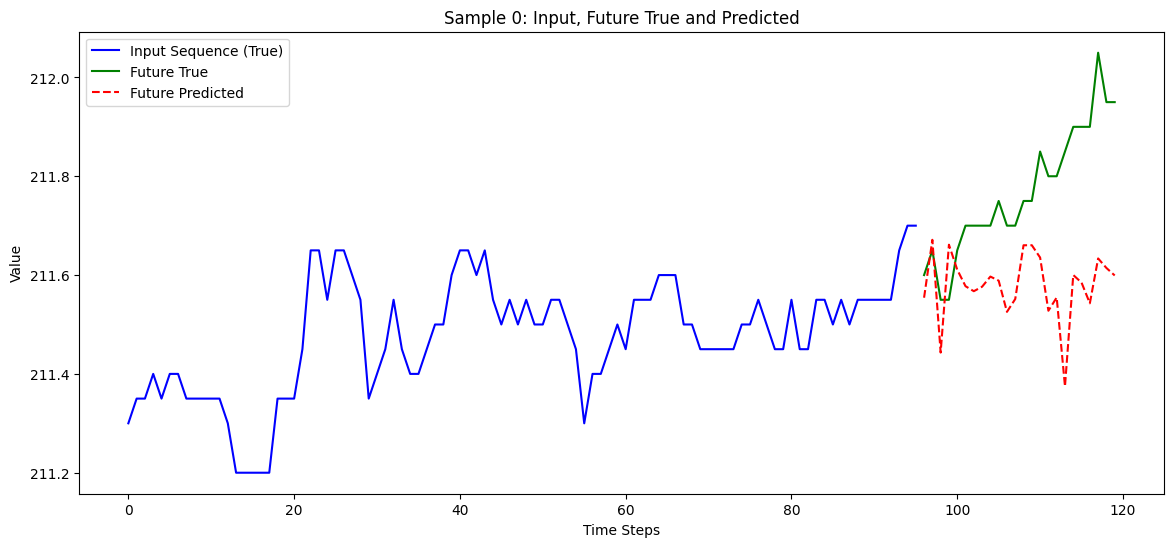

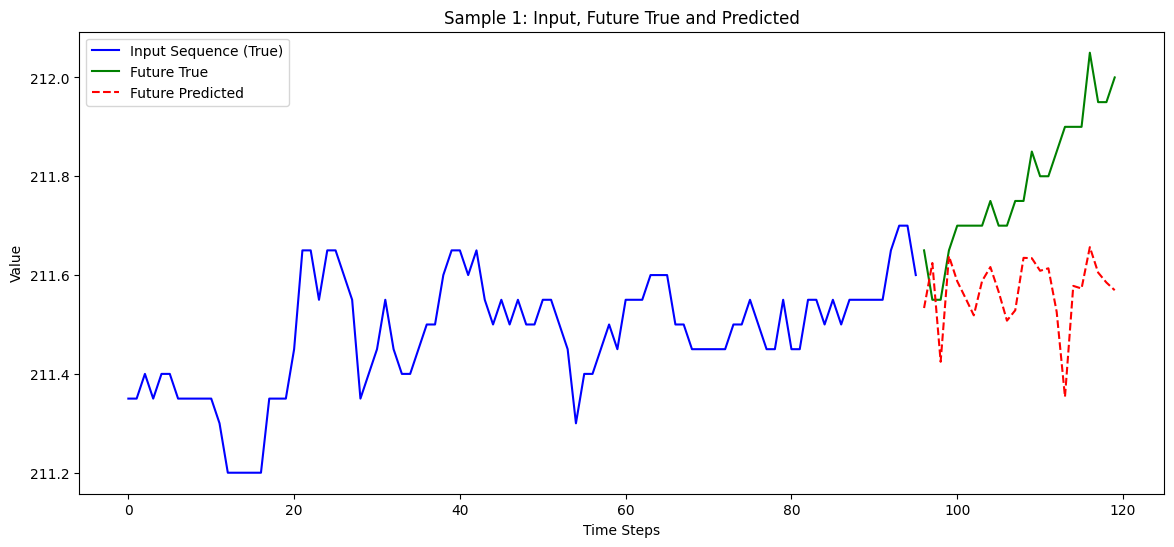

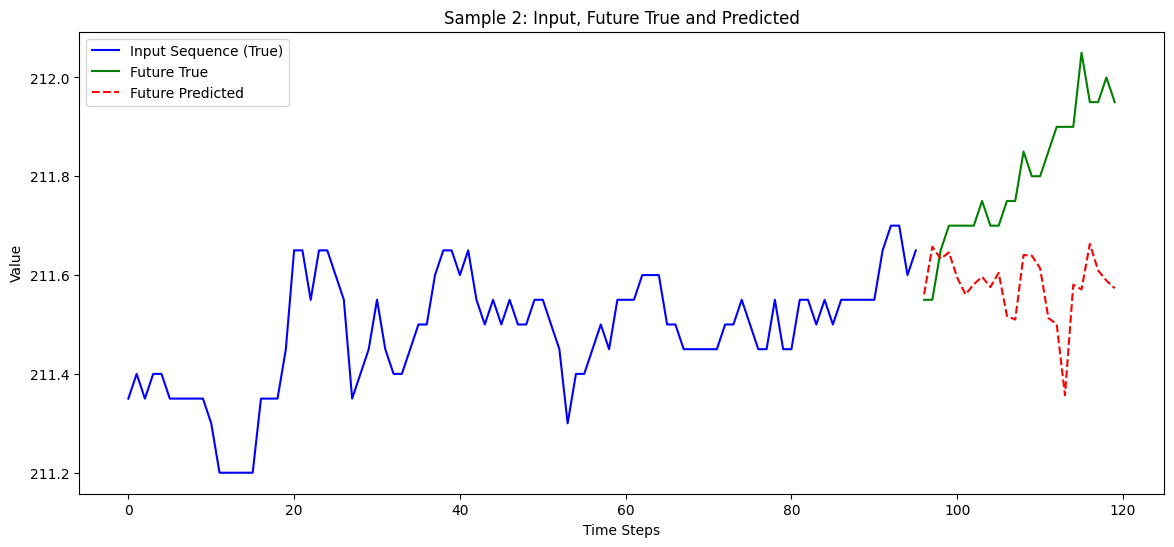

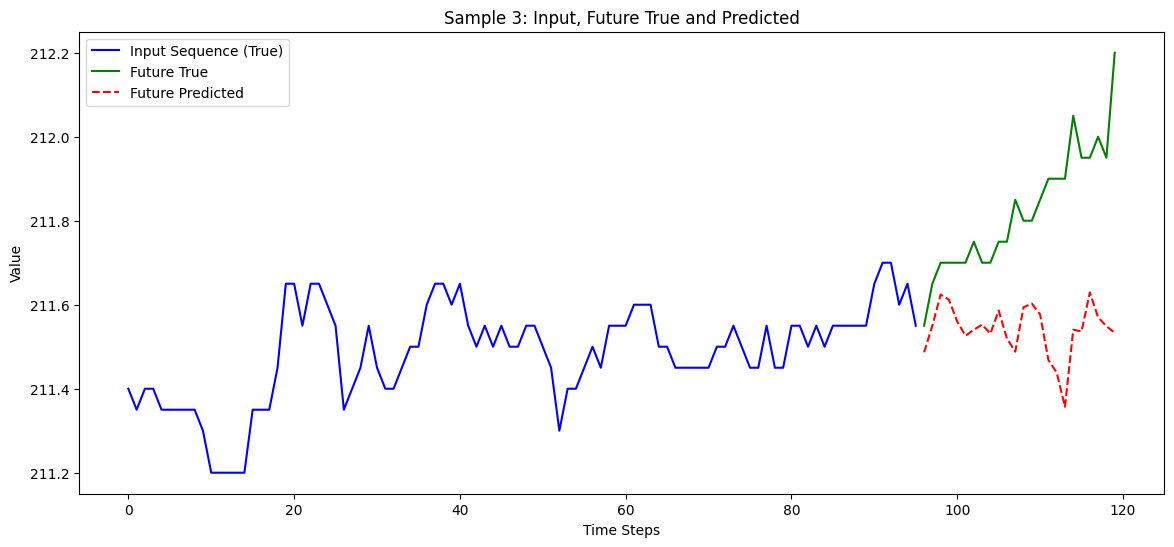

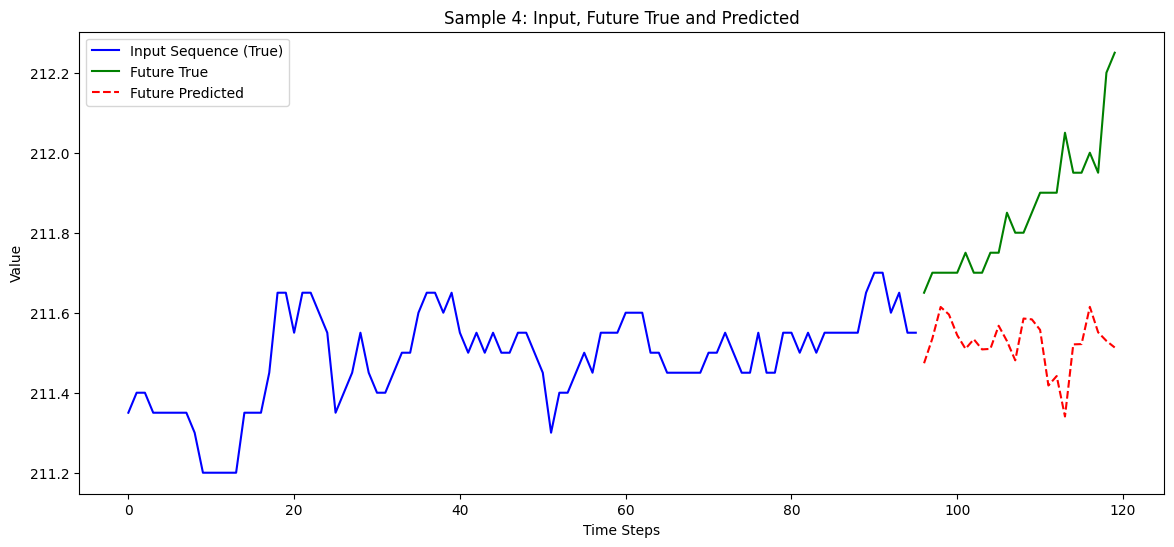

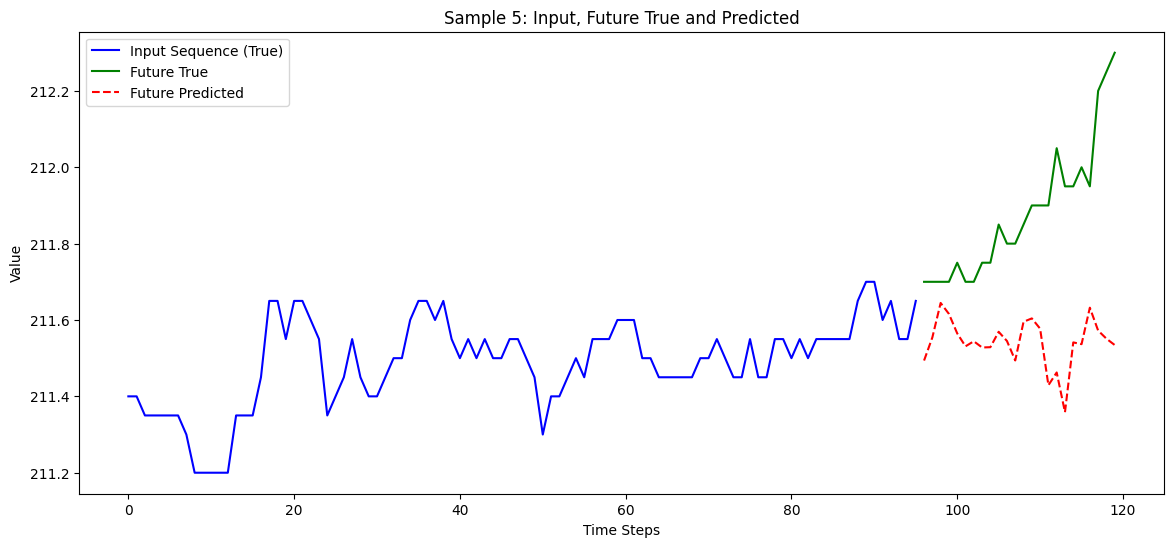

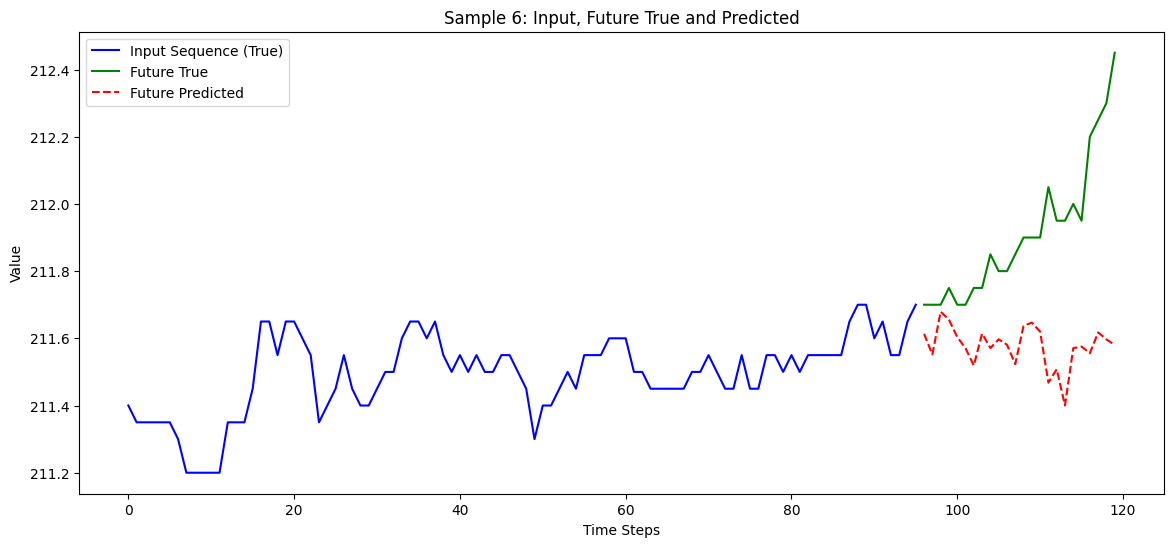

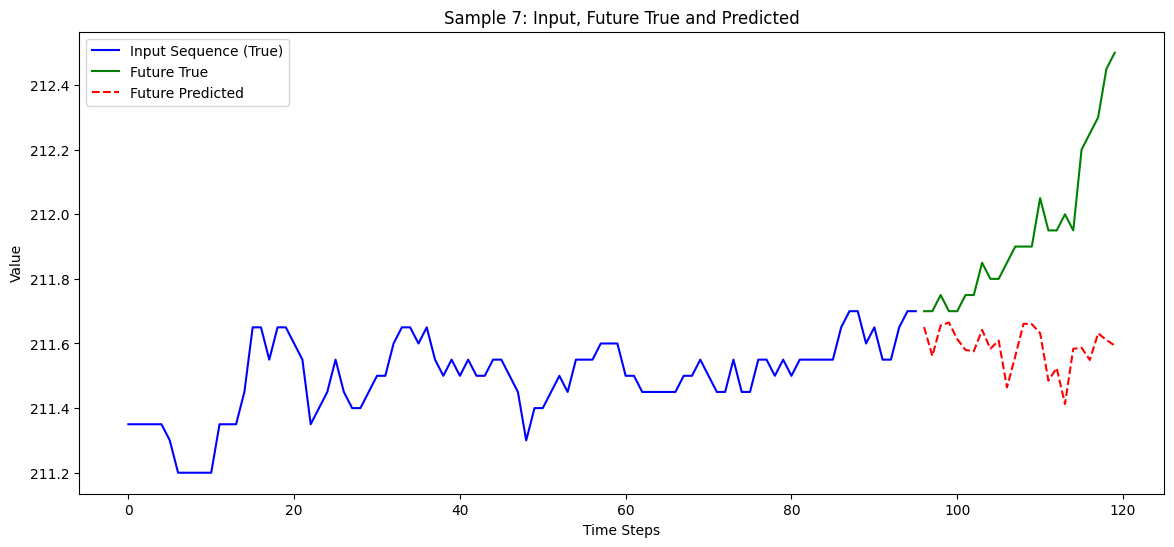

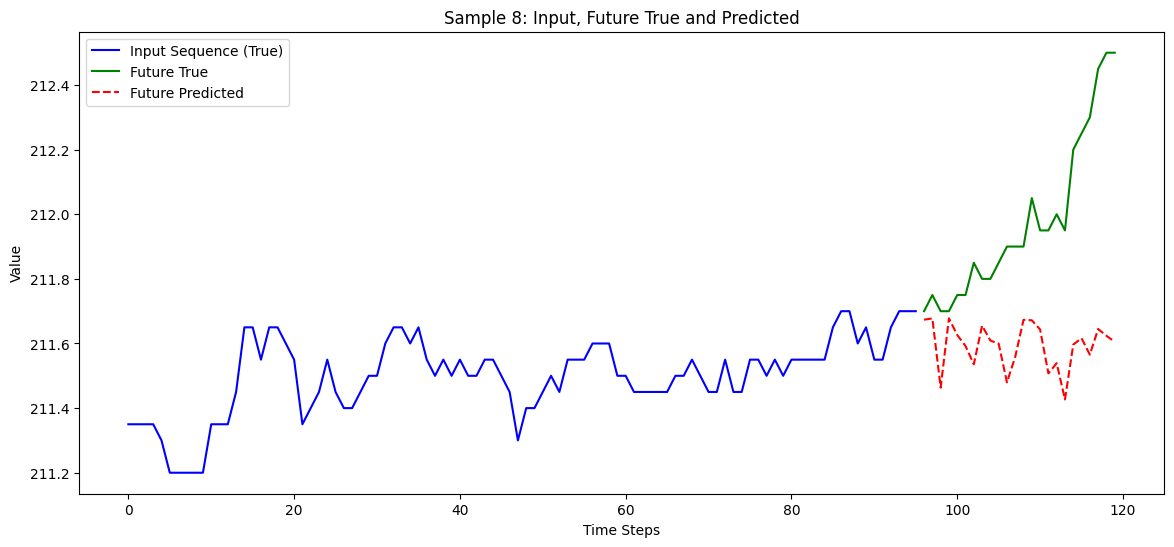

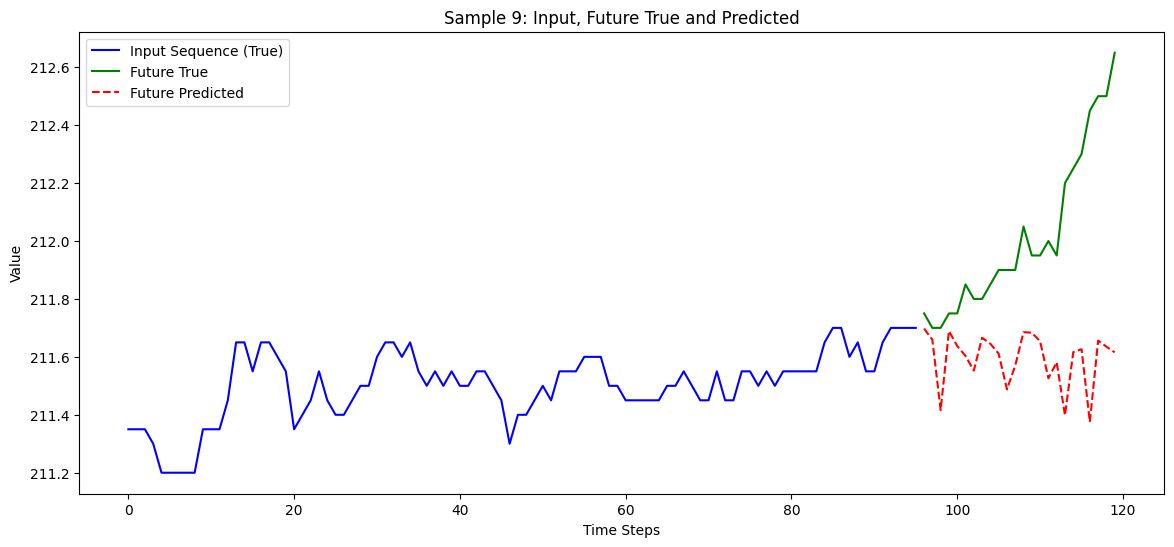

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from data.data_loader import Dataset_Kospi200

results_folder = f'./results/{setting}/'
pred_path = results_folder + 'pred.npy'
true_path = results_folder + 'true.npy'

preds = np.load(pred_path)  # shape: (num_samples, seq_len, features)
trues = np.load(true_path)  # shape: (num_samples, seq_len, features)

print(f"preds shape: {preds.shape}")
print(f"trues shape: {trues.shape}")

dataset = Dataset_Kospi200(
    root_path=args.root_path,
    data_path=args.data_path,
    flag='test',
    size=[args.seq_len, args.label_len, args.pred_len],
    features=args.features,
    target=args.target,
    scale=True,
    inverse=False,
    timeenc=0,
    freq=args.freq
)

# 예: 0부터 4까지 5개 샘플 시각화
for sample_idx in range(min(10, preds.shape[0])):
    feature_idx = 0
    seq_x, seq_y, seq_x_mark, seq_y_mark = dataset[sample_idx]

    seq_x_orig = dataset.inverse_transform(seq_x)
    trues_orig = dataset.inverse_transform(trues[sample_idx])
    preds_orig = dataset.inverse_transform(preds[sample_idx])

    plt.figure(figsize=(14, 6))
    plt.plot(range(args.seq_len), seq_x_orig[:, feature_idx], label='Input Sequence (True)', color='blue')
    plt.plot(range(args.seq_len, args.seq_len + args.pred_len), trues_orig[:, feature_idx], label='Future True', color='green')
    plt.plot(range(args.seq_len, args.seq_len + args.pred_len), preds_orig[:, feature_idx], label='Future Predicted', color='red', linestyle='--')
    plt.title(f'Sample {sample_idx}: Input, Future True and Predicted')
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.show()


# 2. 다변량

In [24]:
# 1. 라이브러리 임포트 및 설정
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from exp.exp_informer import Exp_Informer

# GPU 사용 가능 여부 확인 및 설정
use_gpu = torch.cuda.is_available()
device = torch.device('cuda' if use_gpu else 'cpu')
print("Device:", device)

# 2. Args 직접 정의 (main_informer.py argparse 역할)
class Args:
    model = 'informer'
    data = 'kospi200'
    root_path = '../YOLO-Futures/data/processed/'
    data_path = 'kospi200_ffill_clean_version.pkl'
    features = 'MS'
    target = 'close'
    freq = 'h'
    detail_freq = 'h'
    checkpoints = './checkpoints/'
    seq_len = 96
    label_len = 48
    pred_len = 24
    enc_in = 6
    dec_in = 6
    c_out = 1
    d_model = 512
    n_heads = 8
    e_layers = 2
    d_layers = 1
    s_layers = '3,2,1'
    d_ff = 2048
    factor = 5
    padding = 0
    distil = True
    dropout = 0.05
    attn = 'prob'
    embed = 'timeF'
    activation = 'gelu'
    output_attention = False
    do_predict = True
    mix = True
    cols = None
    num_workers = 0
    itr = 1
    train_epochs = 6
    batch_size = 32
    patience = 3
    learning_rate = 0.0001
    des = 'test'
    loss = 'mse'
    lradj = 'type1'
    use_amp = False
    inverse = False
    use_gpu = use_gpu
    gpu = 0
    use_multi_gpu = False
    devices = '0,1,2,3'
    device_ids = None

args = Args()

# 3. Exp_Informer 객체 생성
exp = Exp_Informer(args)

# 4. 학습 시작
setting = f'{args.model}_{args.data}_ft{args.features}_sl{args.seq_len}_ll{args.label_len}_pl{args.pred_len}_dm{args.d_model}_nh{args.n_heads}_el{args.e_layers}_dl{args.d_layers}_df{args.d_ff}_at{args.attn}_fc{args.factor}_eb{args.embed}_dt{args.distil}_mx{args.mix}_{args.des}_0'

print(f"Training start: {setting}")
model = exp.train(setting)

# 5. 테스트
print(f"Testing start: {setting}")
exp.test(setting)

# 6. 예측 (미래 데이터에 대한)
if args.do_predict:
    print(f"Predicting start: {setting}")
    exp.predict(setting, load=True)



Device: cuda
Use GPU: cuda:0
Training start: informer_kospi200_ftMS_sl96_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0
train 3381
val 477
test 977
	iters: 100, epoch: 1 | loss: 0.1482290
	speed: 0.1184s/iter; left time: 62.8923s
Epoch: 1 cost time: 12.491656064987183
Epoch: 1, Steps: 105 | Train Loss: 0.1980619 Vali Loss: 0.0630303 Test Loss: 0.8320614
Validation loss decreased (inf --> 0.063030).  Saving model ...
Updating learning rate to 0.0001
	iters: 100, epoch: 2 | loss: 0.0766022
	speed: 0.1541s/iter; left time: 65.6512s
Epoch: 2 cost time: 12.34400224685669
Epoch: 2, Steps: 105 | Train Loss: 0.0891060 Vali Loss: 0.0150483 Test Loss: 0.6931025
Validation loss decreased (0.063030 --> 0.015048).  Saving model ...
Updating learning rate to 5e-05
	iters: 100, epoch: 3 | loss: 0.1482173
	speed: 0.1540s/iter; left time: 49.4492s
Epoch: 3 cost time: 12.491553544998169
Epoch: 3, Steps: 105 | Train Loss: 0.0685934 Vali Loss: 0.0211960 Test Loss: 0.5625280
Ear

preds shape: (960, 24, 1)
trues shape: (960, 24, 1)


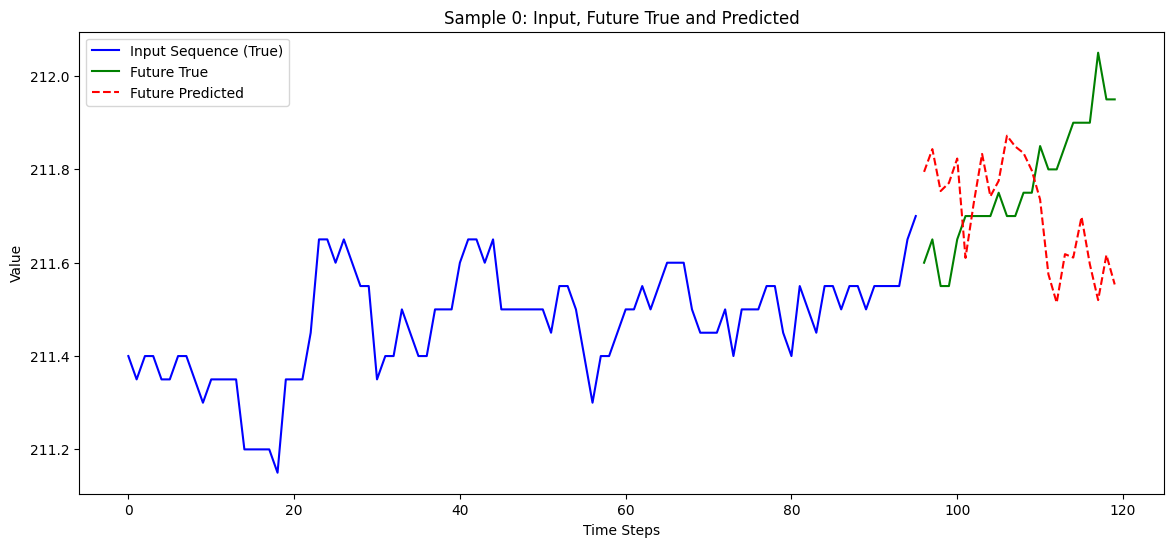

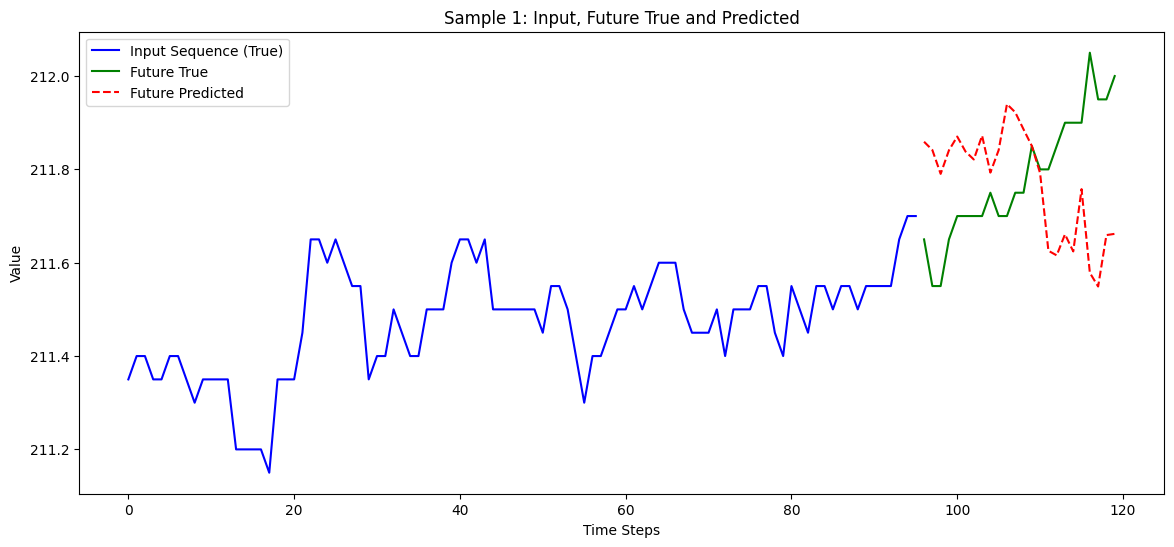

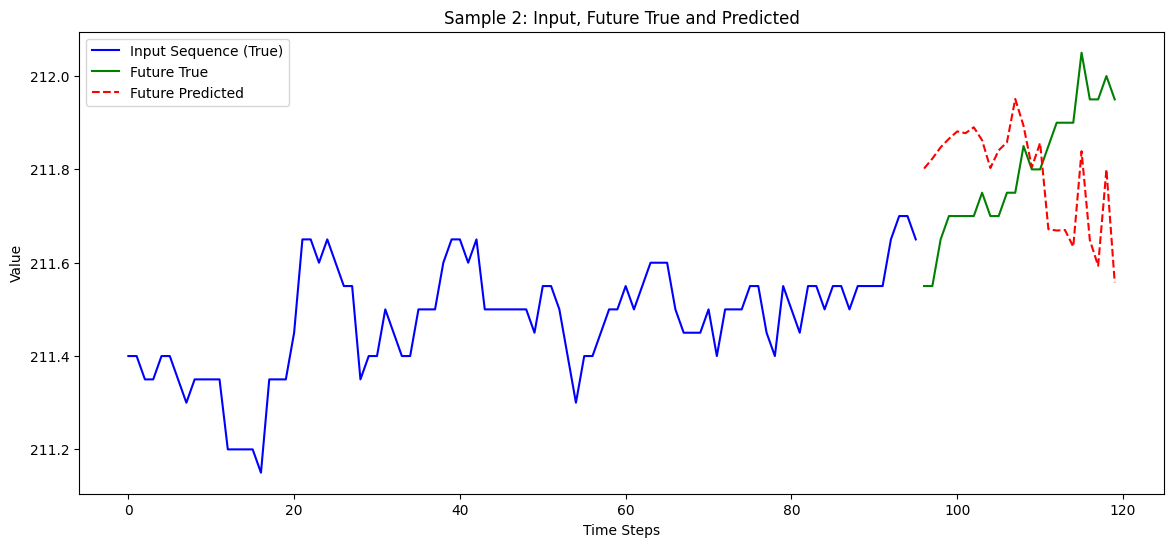

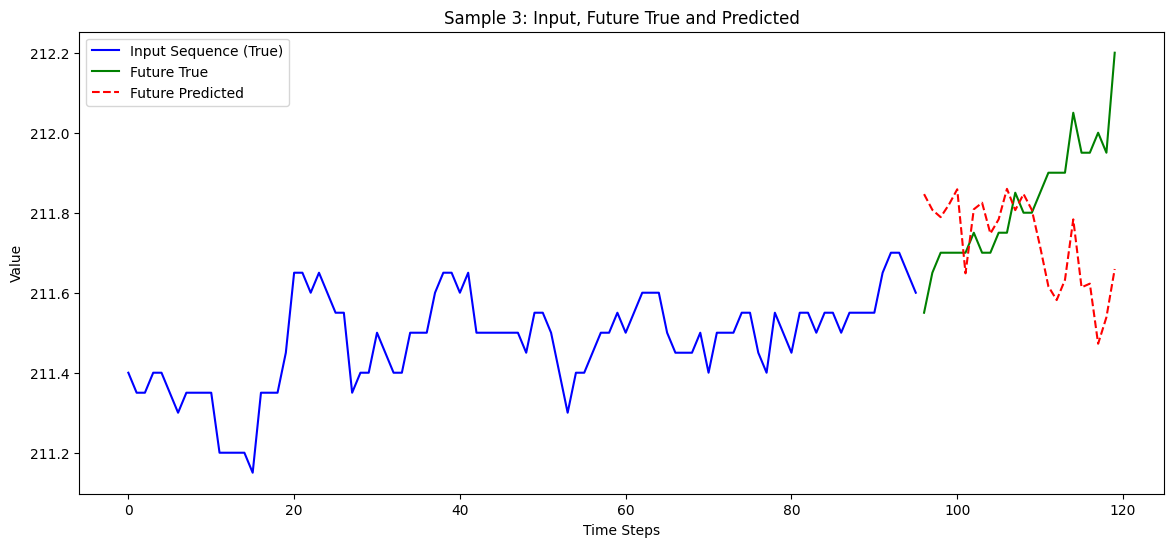

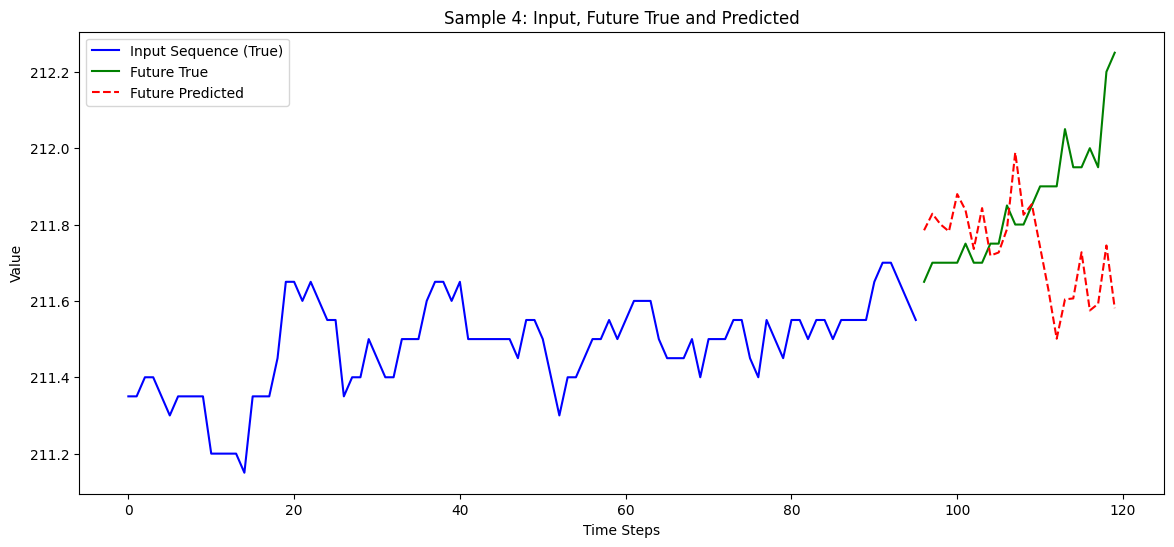

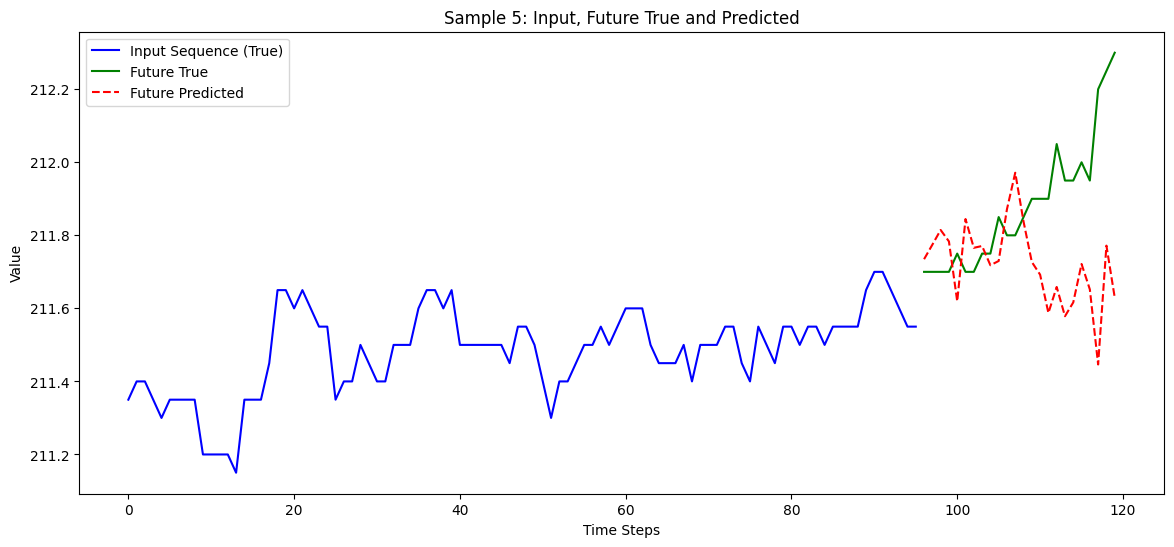

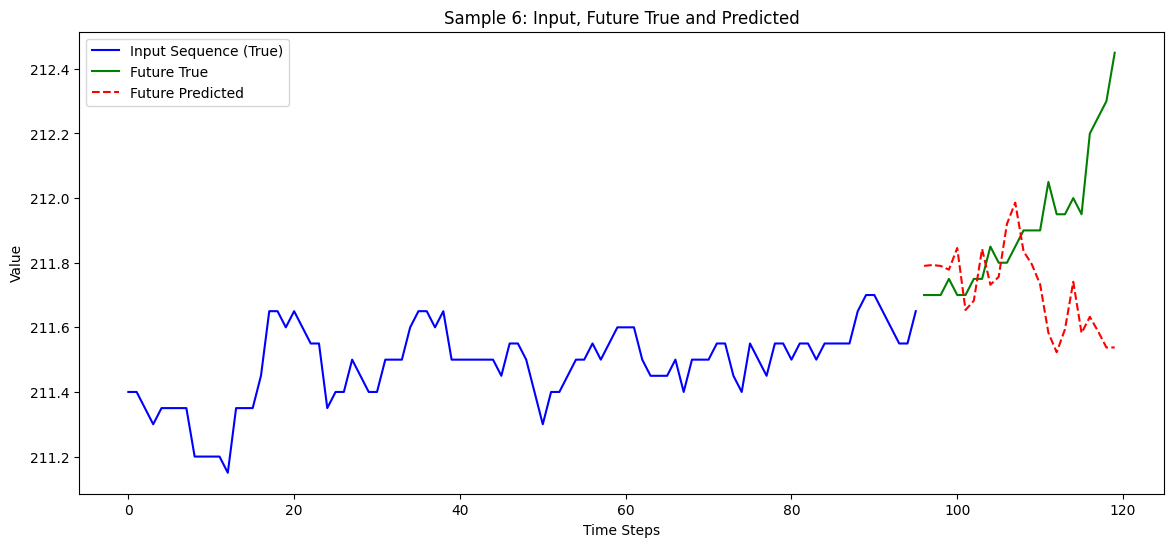

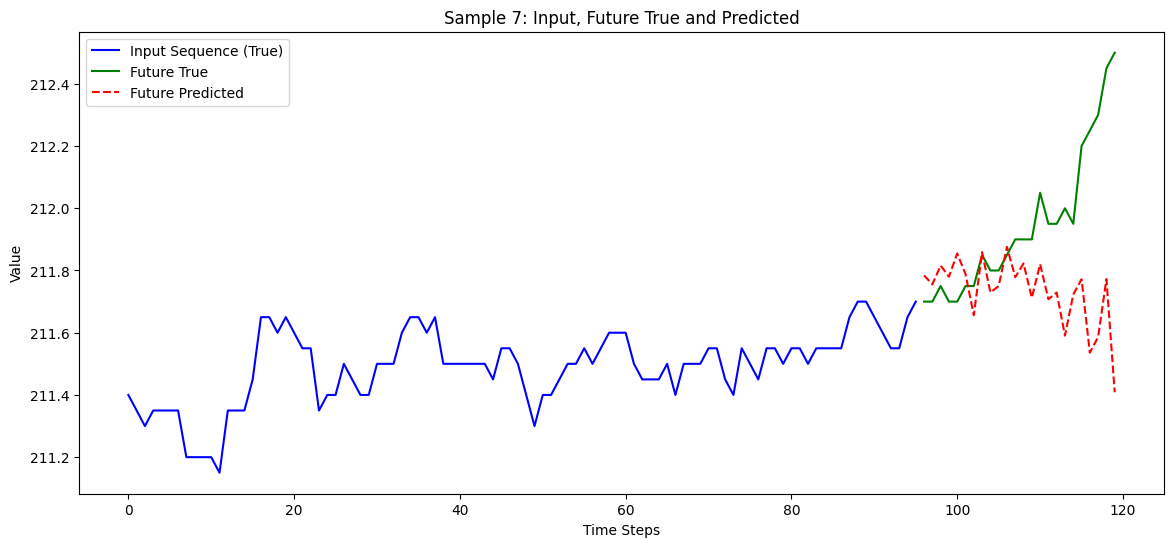

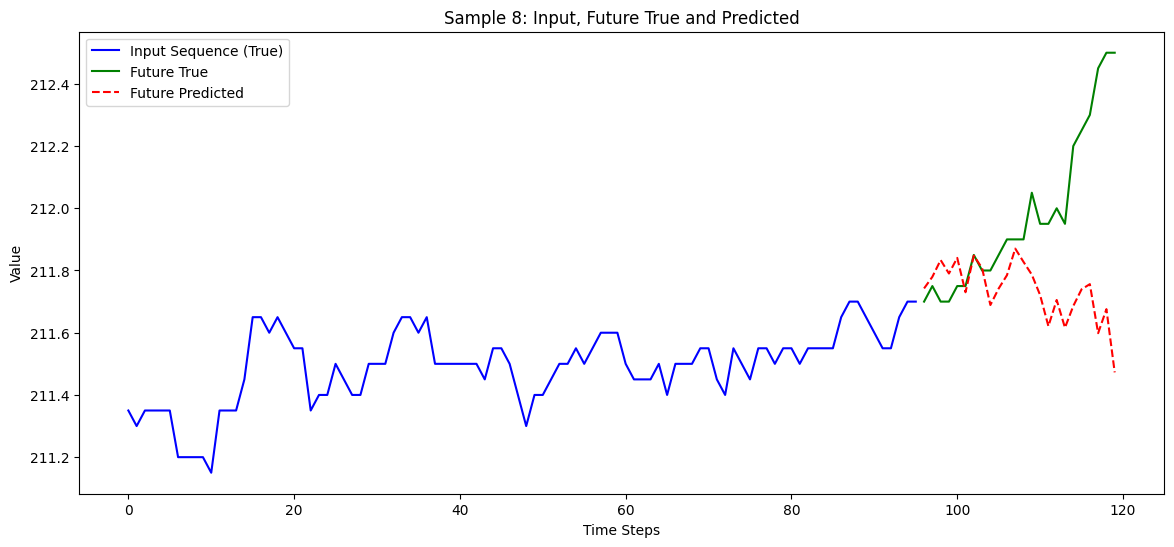

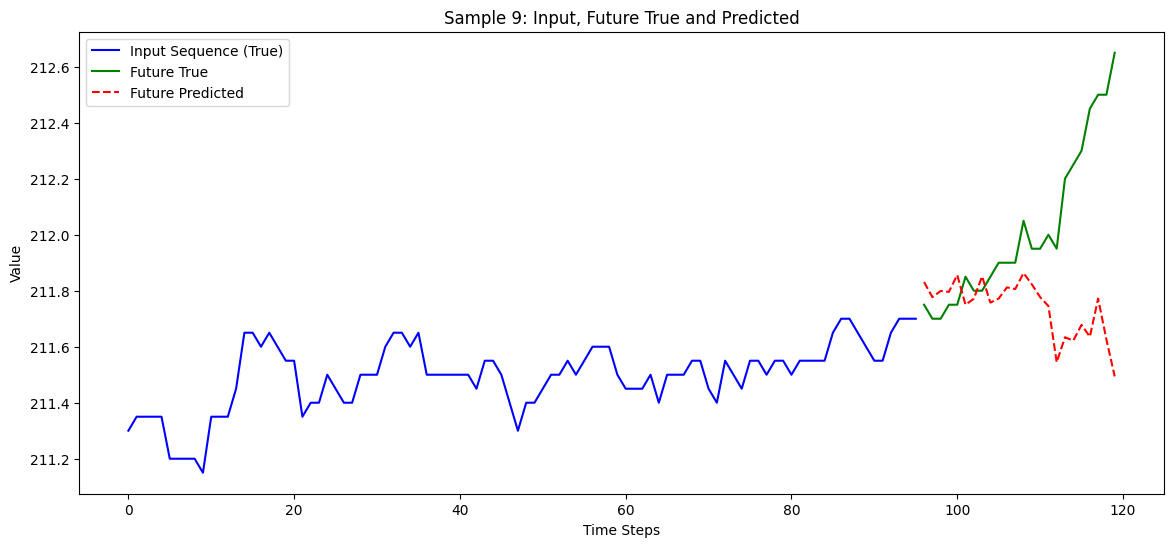

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from data.data_loader import Dataset_Kospi200

results_folder = f'./results/{setting}/'
pred_path = results_folder + 'pred.npy'
true_path = results_folder + 'true.npy'

preds = np.load(pred_path)  # shape: (num_samples, seq_len, features)
trues = np.load(true_path)  # shape: (num_samples, seq_len, features)

print(f"preds shape: {preds.shape}")
print(f"trues shape: {trues.shape}")

dataset = Dataset_Kospi200(
    root_path=args.root_path,
    data_path=args.data_path,
    flag='test',
    size=[args.seq_len, args.label_len, args.pred_len],
    features=args.features,
    target=args.target,
    scale=True,
    inverse=False,
    timeenc=0,
    freq=args.freq
)

# 예: 0부터 4까지 5개 샘플 시각화
for sample_idx in range(min(10, preds.shape[0])):
    feature_idx = 0
    seq_x, seq_y, seq_x_mark, seq_y_mark = dataset[sample_idx]

    seq_x_orig = dataset.inverse_transform(seq_x)
    trues_orig = dataset.inverse_transform(trues[sample_idx])
    preds_orig = dataset.inverse_transform(preds[sample_idx])

    plt.figure(figsize=(14, 6))
    plt.plot(range(args.seq_len), seq_x_orig[:, feature_idx], label='Input Sequence (True)', color='blue')
    plt.plot(range(args.seq_len, args.seq_len + args.pred_len), trues_orig[:, feature_idx], label='Future True', color='green')
    plt.plot(range(args.seq_len, args.seq_len + args.pred_len), preds_orig[:, feature_idx], label='Future Predicted', color='red', linestyle='--')
    plt.title(f'Sample {sample_idx}: Input, Future True and Predicted')
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.show()


# 3. 피처 추가

- ema5만 추가

In [2]:
# 1. 라이브러리 임포트 및 설정
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from exp.exp_informer import Exp_Informer

# GPU 사용 가능 여부 확인 및 설정
use_gpu = torch.cuda.is_available()
device = torch.device('cuda' if use_gpu else 'cpu')
print("Device:", device)

# 2. Args 직접 정의 (main_informer.py argparse 역할)
class Args:
    model = 'informer'
    data = 'kospi200'
    root_path = '../YOLO-Futures/data/processed/'
    data_path = 'kospi200_ffill_clean_version.pkl'
    features = 'MS'
    target = 'close'
    freq = 'h'
    detail_freq = 'h'
    checkpoints = './checkpoints/'
    seq_len = 96
    label_len = 48
    pred_len = 24
    enc_in = 7
    dec_in = 7
    c_out = 1
    d_model = 512
    n_heads = 8
    e_layers = 2
    d_layers = 1
    s_layers = '3,2,1'
    d_ff = 2048
    factor = 5
    padding = 0
    distil = True
    dropout = 0.05
    attn = 'prob'
    embed = 'timeF'
    activation = 'gelu'
    output_attention = False
    do_predict = True
    mix = True
    cols = None
    num_workers = 0
    itr = 1
    train_epochs = 6
    batch_size = 32
    patience = 3
    learning_rate = 0.0001
    des = 'test'
    loss = 'mse'
    lradj = 'type1'
    use_amp = False
    inverse = False
    use_gpu = use_gpu
    gpu = 0
    use_multi_gpu = False
    devices = '0,1,2,3'
    device_ids = None

args = Args()

# 3. Exp_Informer 객체 생성
exp = Exp_Informer(args)

# 4. 학습 시작
setting = f'{args.model}_{args.data}_ft{args.features}_sl{args.seq_len}_ll{args.label_len}_pl{args.pred_len}_dm{args.d_model}_nh{args.n_heads}_el{args.e_layers}_dl{args.d_layers}_df{args.d_ff}_at{args.attn}_fc{args.factor}_eb{args.embed}_dt{args.distil}_mx{args.mix}_{args.des}_0'

print(f"Training start: {setting}")
model = exp.train(setting)

# 5. 테스트
print(f"Testing start: {setting}")
exp.test(setting)

# 6. 예측 (미래 데이터에 대한)
if args.do_predict:
    print(f"Predicting start: {setting}")
    exp.predict(setting, load=True)



Device: cuda
Use GPU: cuda:0
Training start: informer_kospi200_ftMS_sl96_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0
train 3381
val 477
test 977
	iters: 100, epoch: 1 | loss: 0.0297544
	speed: 0.1269s/iter; left time: 67.3748s
Epoch: 1 cost time: 13.33379316329956
Epoch: 1, Steps: 105 | Train Loss: 0.1831414 Vali Loss: 0.0782424 Test Loss: 0.7436725
Validation loss decreased (inf --> 0.078242).  Saving model ...
Updating learning rate to 0.0001
	iters: 100, epoch: 2 | loss: 0.0963752
	speed: 0.1560s/iter; left time: 66.4449s
Epoch: 2 cost time: 12.523617029190063
Epoch: 2, Steps: 105 | Train Loss: 0.0765955 Vali Loss: 0.0360141 Test Loss: 0.7489130
Validation loss decreased (0.078242 --> 0.036014).  Saving model ...
Updating learning rate to 5e-05
	iters: 100, epoch: 3 | loss: 0.0350528
	speed: 0.1547s/iter; left time: 49.6677s
Epoch: 3 cost time: 12.413377523422241
Epoch: 3, Steps: 105 | Train Loss: 0.0540420 Vali Loss: 0.0304723 Test Loss: 0.5734921
Val

preds shape: (960, 24, 1)
trues shape: (960, 24, 1)


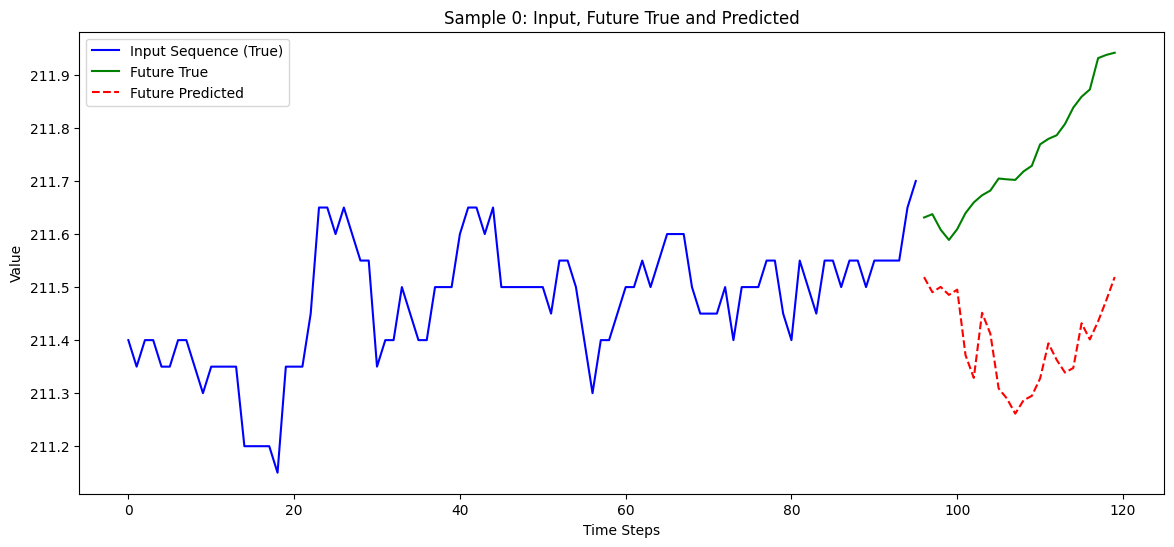

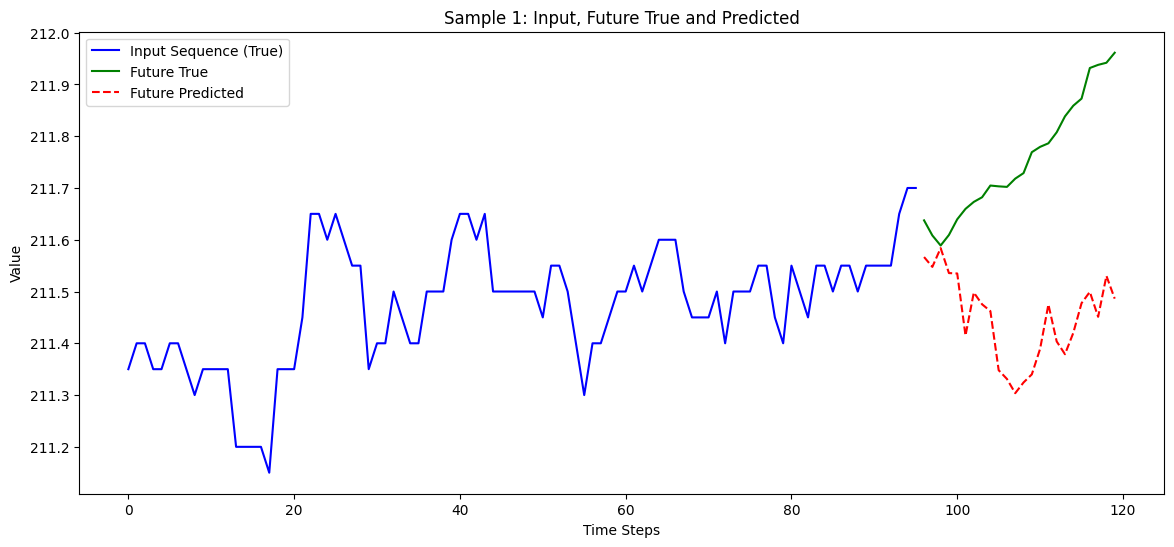

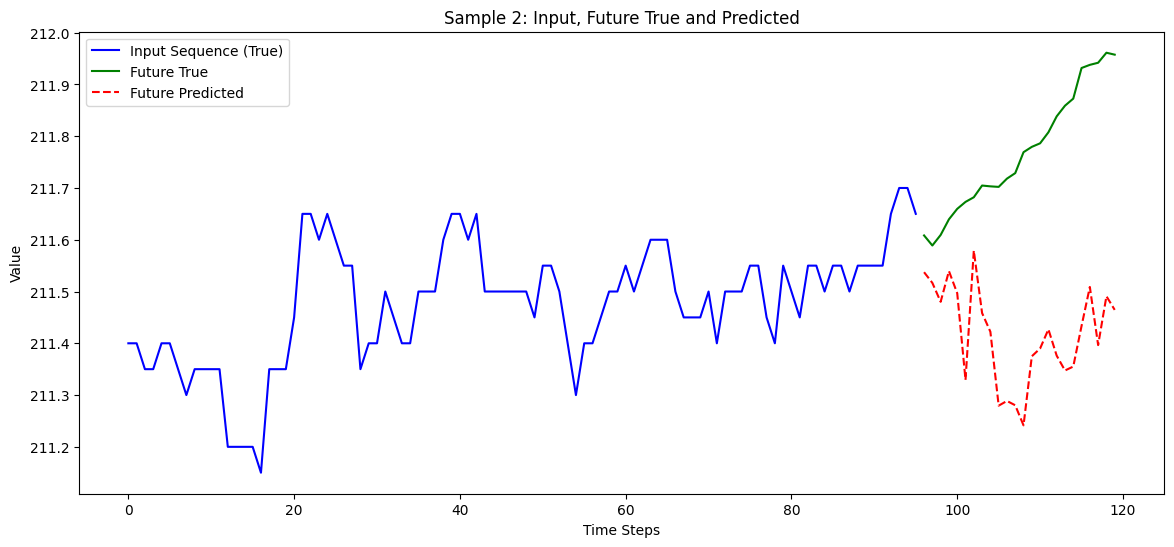

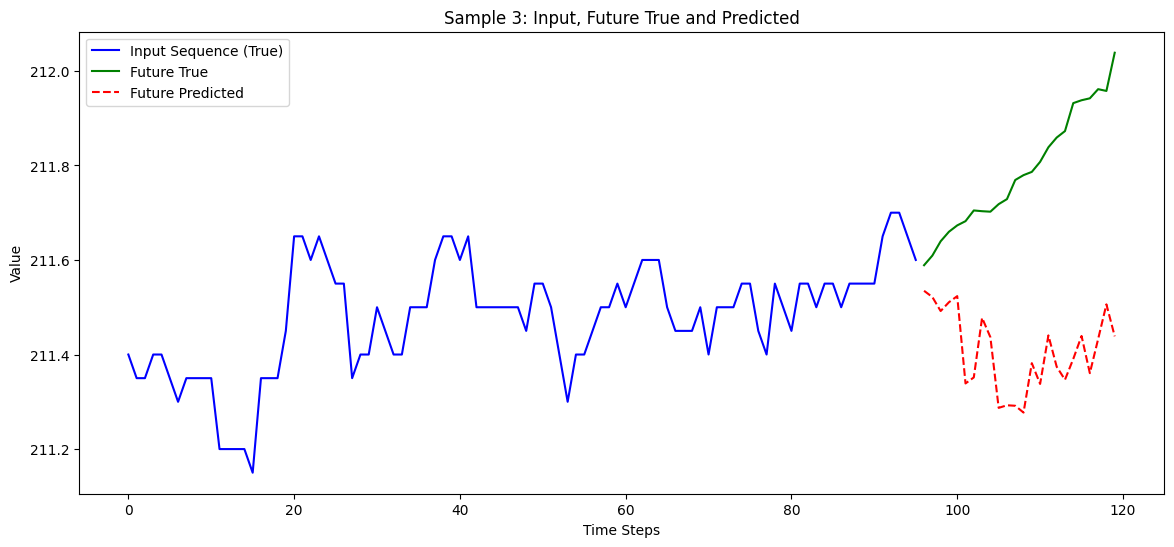

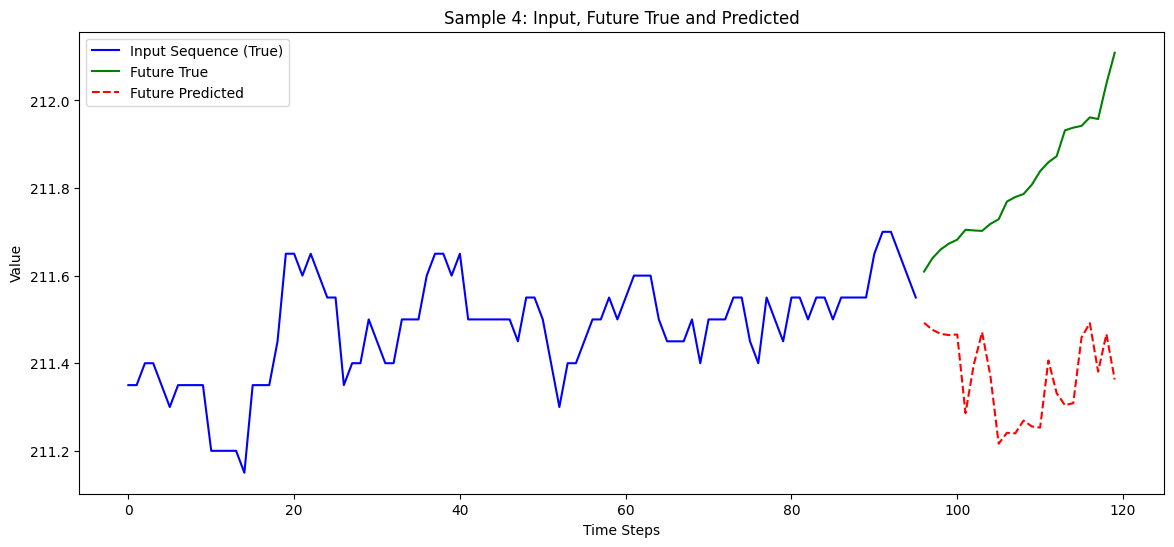

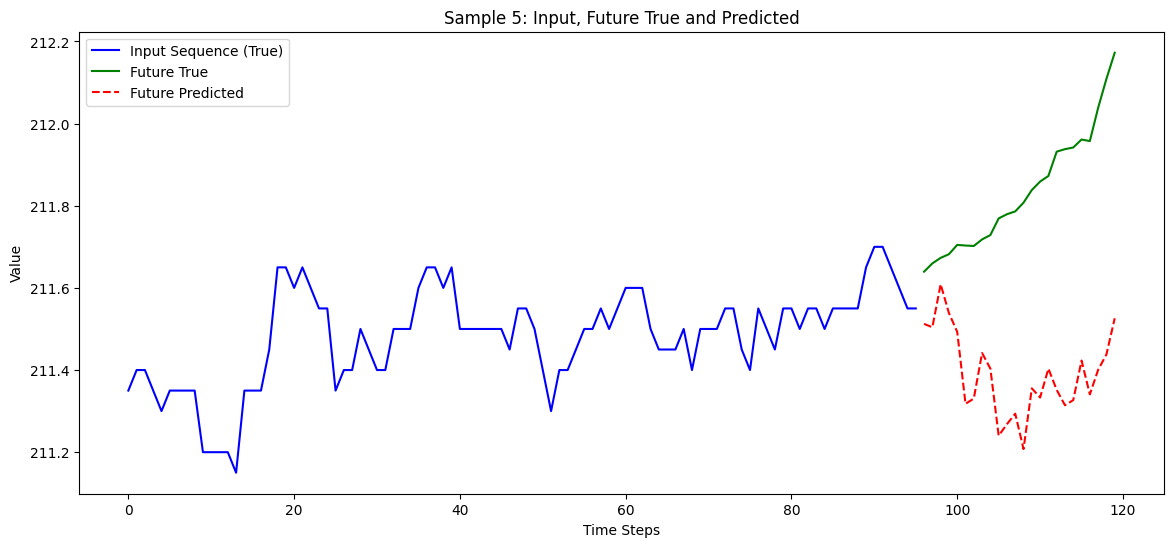

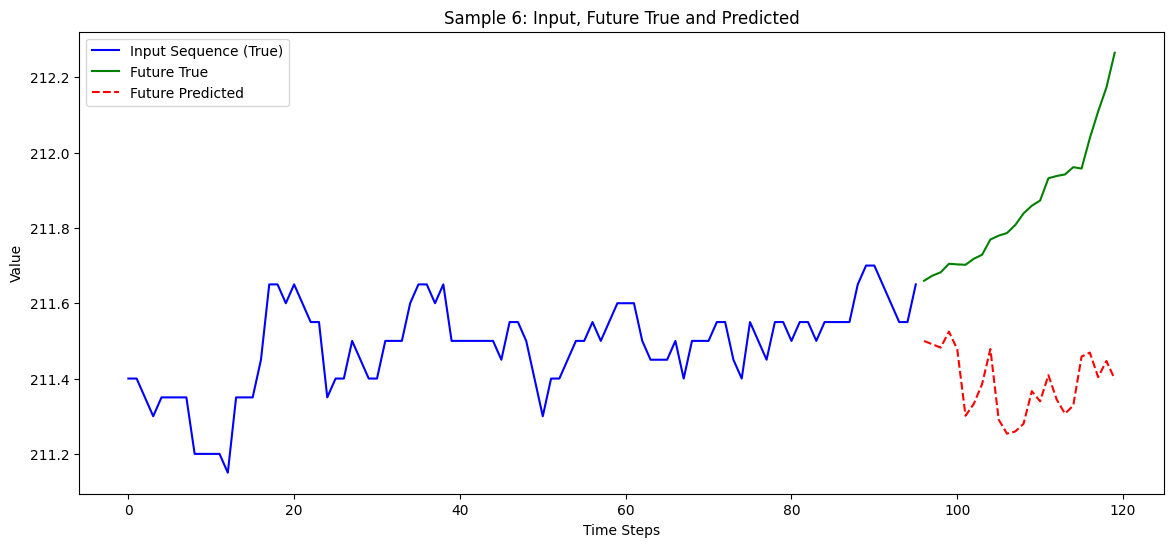

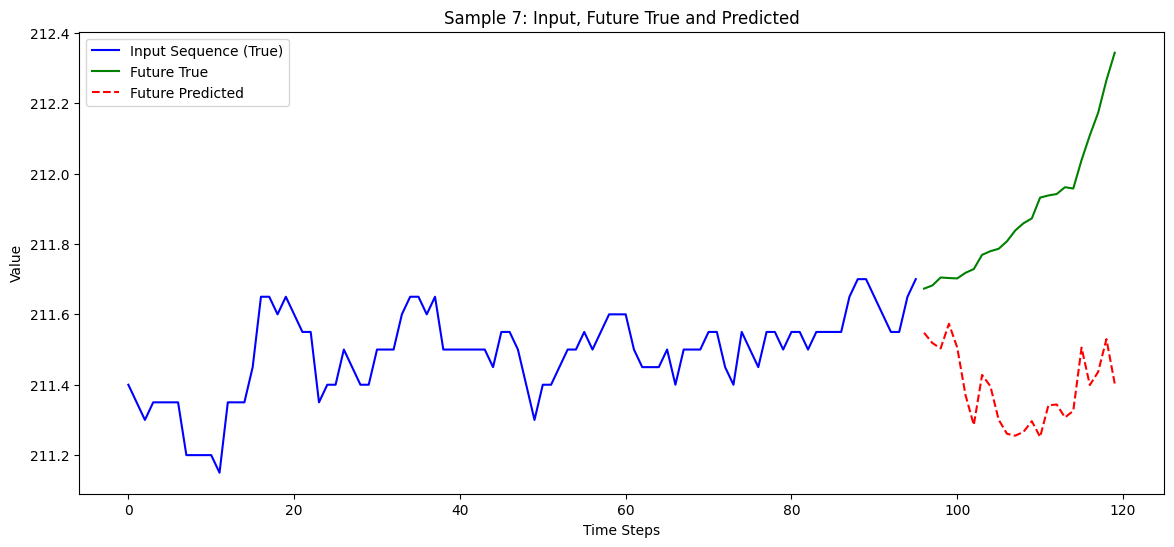

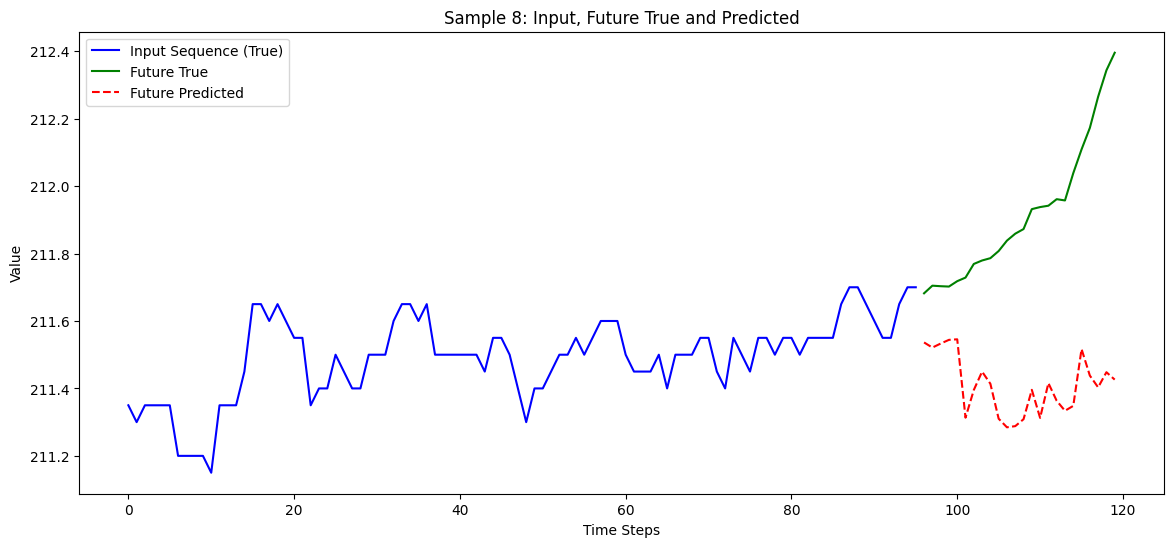

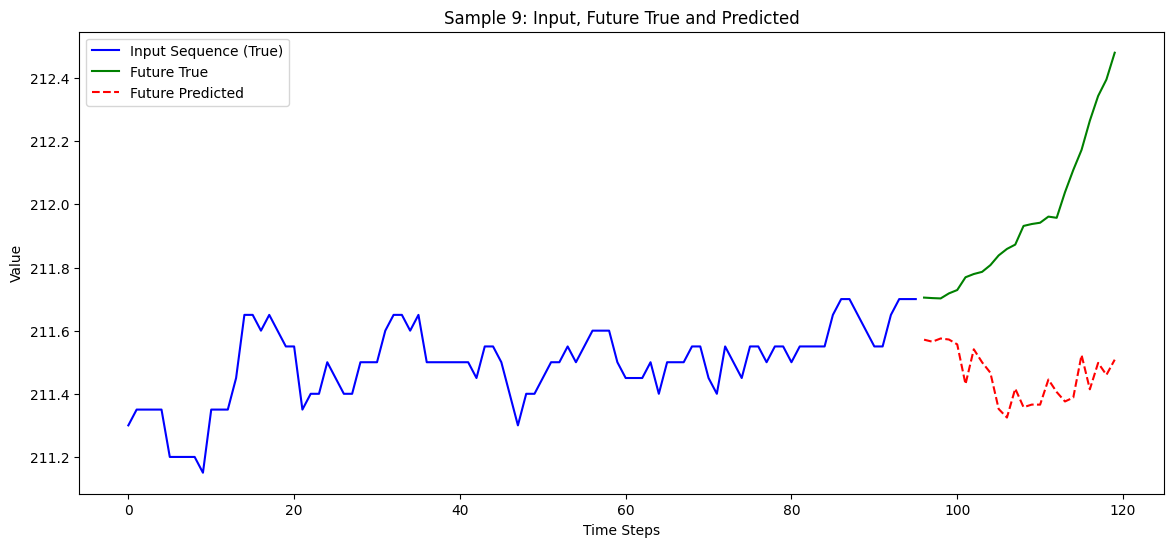

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from data.data_loader import Dataset_Kospi200

results_folder = f'./results/{setting}/'
pred_path = results_folder + 'pred.npy'
true_path = results_folder + 'true.npy'

preds = np.load(pred_path)  # shape: (num_samples, seq_len, features)
trues = np.load(true_path)  # shape: (num_samples, seq_len, features)

print(f"preds shape: {preds.shape}")
print(f"trues shape: {trues.shape}")

dataset = Dataset_Kospi200(
    root_path=args.root_path,
    data_path=args.data_path,
    flag='test',
    size=[args.seq_len, args.label_len, args.pred_len],
    features=args.features,
    target=args.target,
    scale=True,
    inverse=False,
    timeenc=0,
    freq=args.freq
)

# 예: 0부터 4까지 5개 샘플 시각화
for sample_idx in range(min(10, preds.shape[0])):
    feature_idx = 0
    seq_x, seq_y, seq_x_mark, seq_y_mark = dataset[sample_idx]

    seq_x_orig = dataset.inverse_transform(seq_x)
    trues_orig = dataset.inverse_transform(trues[sample_idx])
    preds_orig = dataset.inverse_transform(preds[sample_idx])

    plt.figure(figsize=(14, 6))
    plt.plot(range(args.seq_len), seq_x_orig[:, feature_idx], label='Input Sequence (True)', color='blue')
    plt.plot(range(args.seq_len, args.seq_len + args.pred_len), trues_orig[:, feature_idx], label='Future True', color='green')
    plt.plot(range(args.seq_len, args.seq_len + args.pred_len), preds_orig[:, feature_idx], label='Future Predicted', color='red', linestyle='--')
    plt.title(f'Sample {sample_idx}: Input, Future True and Predicted')
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.show()


- 나머지 싹다 추가

In [2]:
# 1. 라이브러리 임포트 및 설정
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from exp.exp_informer import Exp_Informer

# GPU 사용 가능 여부 확인 및 설정
use_gpu = torch.cuda.is_available()
device = torch.device('cuda' if use_gpu else 'cpu')
print("Device:", device)

# 2. Args 직접 정의 (main_informer.py argparse 역할)
class Args:
    model = 'informer'
    data = 'kospi200'
    root_path = '../YOLO-Futures/data/processed/'
    data_path = 'kospi200_ffill_clean_version.pkl'
    features = 'MS'
    target = 'close'
    freq = 'h'
    detail_freq = 'h'
    checkpoints = './checkpoints/'
    seq_len = 96
    label_len = 48
    pred_len = 24
    enc_in = 26
    dec_in = 26
    c_out = 1
    d_model = 512
    n_heads = 8
    e_layers = 2
    d_layers = 1
    s_layers = '3,2,1'
    d_ff = 2048
    factor = 5
    padding = 0
    distil = True
    dropout = 0.05
    attn = 'prob'
    embed = 'timeF'
    activation = 'gelu'
    output_attention = False
    do_predict = True
    mix = True
    cols = None
    num_workers = 0
    itr = 1
    train_epochs = 6
    batch_size = 32
    patience = 3
    learning_rate = 0.0001
    des = 'test'
    loss = 'mse'
    lradj = 'type1'
    use_amp = False
    inverse = False
    use_gpu = use_gpu
    gpu = 0
    use_multi_gpu = False
    devices = '0,1,2,3'
    device_ids = None

args = Args()

# 3. Exp_Informer 객체 생성
exp = Exp_Informer(args)

# 4. 학습 시작
setting = f'{args.model}_{args.data}_ft{args.features}_sl{args.seq_len}_ll{args.label_len}_pl{args.pred_len}_dm{args.d_model}_nh{args.n_heads}_el{args.e_layers}_dl{args.d_layers}_df{args.d_ff}_at{args.attn}_fc{args.factor}_eb{args.embed}_dt{args.distil}_mx{args.mix}_{args.des}_0'

print(f"Training start: {setting}")
model = exp.train(setting)

# 5. 테스트
print(f"Testing start: {setting}")
exp.test(setting)

# 6. 예측 (미래 데이터에 대한)
if args.do_predict:
    print(f"Predicting start: {setting}")
    exp.predict(setting, load=True)



Device: cuda
Use GPU: cuda:0
Training start: informer_kospi200_ftMS_sl96_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0
train 3381
val 477
test 977
	iters: 100, epoch: 1 | loss: 0.0808964
	speed: 0.1242s/iter; left time: 65.9510s
Epoch: 1 cost time: 13.055269002914429
Epoch: 1, Steps: 105 | Train Loss: 0.2228802 Vali Loss: 0.1387438 Test Loss: 0.1531951
Validation loss decreased (inf --> 0.138744).  Saving model ...
Updating learning rate to 0.0001
	iters: 100, epoch: 2 | loss: 0.0909946
	speed: 0.1581s/iter; left time: 67.3702s
Epoch: 2 cost time: 12.236026763916016
Epoch: 2, Steps: 105 | Train Loss: 0.0962416 Vali Loss: 0.1793574 Test Loss: 0.1211550
EarlyStopping counter: 1 out of 3
Updating learning rate to 5e-05
	iters: 100, epoch: 3 | loss: 0.0276790
	speed: 0.1586s/iter; left time: 50.9124s
Epoch: 3 cost time: 12.288398742675781
Epoch: 3, Steps: 105 | Train Loss: 0.0620923 Vali Loss: 0.1829560 Test Loss: 0.1359311
EarlyStopping counter: 2 out of 3
Upd